# Cross-validated fine-tuning (E6)

The same seven checkpoints and the same data as notebook 04, differing in
one thing: how the number of training epochs is decided, and therefore how
much of the training set reaches the model that gets evaluated.

**Notebook 04** holds out 20 percent of the training participants once,
early-stops on them, and evaluates that model. Twenty-two people never
contribute a gradient, and the stopping decision rests on those same
twenty-two.

**This notebook** runs a grouped, stratified 5-fold cross-validation over
the training participants. Each fold early-stops on its own validation part,
the five chosen budgets are pooled with a median, and the model that is
evaluated is refitted on **all** the training rows for that many epochs with
no early stopping. It is the scheme notebooks 01-03 use for their
regressors, and the one Section 9b of the protocol set aside as too
expensive when e5-large was the constraint.

The median rather than the mean: a fold that stops at epoch 1, which the
five-seed runs of notebook 04 showed does happen, would drag a mean budget
down for every other fold.

**Two numbers come out, and they are not interchangeable.**

- *CV RMSE* is computed from out-of-fold predictions, so no training row is
  scored by a model that saw it. It never touches the test set, and it is
  the honest estimate of how the method generalizes.
- *Test RMSE* comes from the refitted model on the 48 held-out participants.
  It is the number that compares with every other arm in the study.

Results go to `results/fine-tuning-cv/`, a separate tree from notebook 04's,
and every row carries `search="finetuned_cv"` so no groupby can pool the two
schemes into one average.

**Cost.** Six trainings per arm and target instead of one. Budget roughly
six times notebook 04: on the order of three to five hours for all seven
arms at one seed.

In [1]:
%load_ext autoreload
%autoreload 2

import sys
import time
import warnings
from dataclasses import replace
from pathlib import Path

warnings.filterwarnings("ignore")

PROJECT_DIR = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(PROJECT_DIR))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from IPython.display import display

from src import config, data, splits, logging_utils
from src.finetuning import run_finetune_cv_arm
from src.pipeline import TARGETS, build_train_frame, expand_to_questions
from src.plotting import plot_confusion_matrix, BAND_LABELS, SCREENING_LABELS

## Run configuration

Identical to notebook 04 except for `n_cv_splits`. Keeping every other
setting the same is what makes the comparison between the two notebooks a
comparison of the epoch-selection scheme rather than of the training recipe.

In [2]:
ARMS = {
    # Capacity ladder on one pretraining recipe.
    "E5_E5SMALL_FT":  "intfloat/multilingual-e5-small",              # 118M / 86M enc
    "E5_E5BASE_FT":   "intfloat/multilingual-e5-base",               # 278M / 86M enc
    "E5_E5LARGE_FT":  "intfloat/multilingual-e5-large",              # 560M / 303M enc
    # Spanish-only pretraining.
    "E5_BETO_FT":     "dccuchile/bert-base-spanish-wwm-cased",       # 110M / 86M enc
    "E5_BERTIN_FT":   "bertin-project/bertin-roberta-base-spanish",  # 125M / 86M enc
    # Architecture pair: same corpus and size, different attention.
    "E5_MDEBERTA_FT": "microsoft/mdeberta-v3-base",                  # 279M / 86M enc
    "E5_XLMR_FT":     "xlm-roberta-base",                            # 278M / 86M enc
    # e5-large's own backbone, at the same size. Without it the e5-large arm
    # has no control: its nearest one is xlm-roberta-BASE, so the gap between
    # them mixes 303M of encoder against 86M with e5's contrastive
    # pretraining against none. This pairing isolates the second.
    "E5_XLMRLARGE_FT": "xlm-roberta-large",                          # 560M / 303M enc
    # Adapted encoders (Phase C), fine-tuned from the same recipe as the arms
    # above, so each is paired with the arm it started from.
    "E8_BETO_MLM_FT": str(config.MODELS_DIR / "mlm_beto" / "ep010"),   # BETO + our MLM/TAPT
    "E8_ROBERTAES_MENTAL_FT": config.MENTAL_ES_MODEL,                  # 355M / 303M enc
}

cfg = config.FineTuningCVConfig(
    # Must match notebook 04's setting: the paired comparison at the end
    # reads both families from the same augmentation tree.
    augmentation=config.AUGMENTATION_LLM,   # <- AUGMENTATION_NONE  AUGMENTATION_LLM
    seeds=(42,),
    n_cv_splits=5,
    max_epochs=20,
    patience=4,
    batch_size=16,
    grad_accum_steps=1,
    max_tokens=512,
    lr_head=1e-4,
    lr_encoder_top=3e-5,
    llrd_decay=0.9,
    warmup_ratio=0.10,
    use_bf16=True,
)

# Same escape hatch as notebook 04; see the note on e5-large there.
OVERRIDES = {}

device = "cuda" if torch.cuda.is_available() else "cpu"
if device == "cuda":
    free, total = torch.cuda.mem_get_info()
    print(f"device: {torch.cuda.get_device_name(0)}  |  VRAM free {free/1e9:.1f} / {total/1e9:.1f} GB")
else:
    print("WARNING: no CUDA device; fine-tuning on CPU is impractical here")
print(f"{cfg.n_cv_splits} folds + 1 refit = {cfg.n_cv_splits + 1} trainings "
      f"per arm and target")
cfg

device: NVIDIA GeForce RTX 4060 Ti  |  VRAM free 16.0 / 17.2 GB
5 folds + 1 refit = 6 trainings per arm and target


FineTuningCVConfig(augmentation='augmented', seeds=(42,), max_epochs=20, patience=4, batch_size=16, eval_batch_size=32, grad_accum_steps=1, max_tokens=512, lr_head=0.0001, lr_encoder_top=3e-05, llrd_decay=0.9, weight_decay=0.01, warmup_ratio=0.1, max_grad_norm=1.0, val_fraction=0.2, use_bf16=True, n_cv_splits=5)

In [3]:
df = data.load_dataset()
train_ids, test_ids = splits.train_test_participants(df)
train_frame, aug_groups = build_train_frame(df, train_ids, test_ids, config.TrainingConfig(
    augmentation=cfg.augmentation))
test_frame = df.loc[test_ids]

group_col = "original_participant" if aug_groups is not None else None
q_train = expand_to_questions(train_frame, group_col=group_col)
q_test = expand_to_questions(test_frame)

groups = q_train["group"].to_numpy()
test_groups = q_test["participant"].to_numpy()
N_TEST = len(test_frame)

print(f"train: {len(train_frame)} rows -> {len(q_train)} question rows, "
      f"{len(np.unique(groups))} people")
print(f"test:  {N_TEST} participants -> {len(q_test)} question rows "
      f"(evaluated per participant)")

train: 220 rows -> 752 question rows, 110 people
test:  48 participants -> 168 question rows (evaluated per participant)


Fold sizes, before running anything. Every fold must keep all of a
person's answers on one side; the check below is the same guarantee the
frozen notebooks rely on.

In [4]:
splitter = splits.cv_splitter(groups=groups, n_splits=cfg.n_cv_splits,
                               random_state=cfg.seeds[0])
folds = list(splitter.split(q_train["text"].to_numpy(),
                             splits.stratify_key(q_train), groups=groups))

rows = []
for k, (fit_idx, val_idx) in enumerate(folds, start=1):
    fit_people, val_people = set(groups[fit_idx]), set(groups[val_idx])
    rows.append({"fold": k, "fit_rows": len(fit_idx), "fit_people": len(fit_people),
                  "val_rows": len(val_idx), "val_people": len(val_people),
                  "people_overlap": len(fit_people & val_people)})
display(pd.DataFrame(rows))
assert all(r["people_overlap"] == 0 for r in rows), "a participant spans two folds"
print("Every training participant is scored out of fold exactly once, and no "
      "participant appears on both sides of any fold.")

,fold,fit_rows,fit_people,val_rows,val_people,people_overlap
0,1,596,88,156,22,0
1,2,602,88,150,22,0
2,3,608,89,144,21,0
3,4,600,87,152,23,0
4,5,602,88,150,22,0


Every training participant is scored out of fold exactly once, and no participant appears on both sides of any fold.


In [5]:
def report_arm(arm, run_rows):
    runs = pd.DataFrame(run_rows)
    params = list(runs["selected_params"])

    print(f"[TEST] {arm}: RMSE / MAE / R2 on the {N_TEST} held-out participants")
    display(runs.pivot(index="seed", columns="target", values=["rmse", "mae", "r2"]).round(3))

    print("[CROSS-VALIDATION on training data] out-of-fold RMSE, and the epoch "
          "budget each fold chose. This is not a test score.")
    display(pd.DataFrame({
        "target": runs["target"],
        "seed": runs["seed"],
        "cv_rmse": [p["cv_rmse"] for p in params],
        "cv_r2": [p["cv_r2"] for p in params],
        "fold_epochs": [p["fold_epochs"] for p in params],
        "refit_epochs": [p["refit_epochs"] for p in params],
    }).set_index(["target", "seed"]))

    fig, axes = plt.subplots(2, 2, figsize=(9, 8))
    for i, target in enumerate(TARGETS):
        target_runs = runs[runs["target"] == target]
        best = target_runs.loc[target_runs["rmse"].idxmin()]
        seed = int(best["seed"])
        plot_confusion_matrix(axes[i, 0], best["band_confusion_matrix"], BAND_LABELS,
                                f"{target} severity bands (seed={seed})")
        plot_confusion_matrix(axes[i, 1], best["screening_confusion_matrix"], SCREENING_LABELS,
                                f"{target} screening, cutoff 10 (seed={seed})")
    plt.suptitle(f"[TEST] {arm}: derived from the same continuous prediction")
    plt.tight_layout()
    plt.show()


def train_and_report(arm):
    arm_cfg = replace(cfg, **OVERRIDES.get(arm, {}))
    t0 = time.time()
    rows = run_finetune_cv_arm(arm, ARMS[arm], q_train, q_test, groups, test_groups,
                                arm_cfg, device)
    print(f"{arm} done in {(time.time()-t0)/60:.1f} min")
    report_arm(arm, rows)

## Arms

Same order as notebook 04: the six base-size arms before e5-large. Each cell
is independent, so an arm can be run or skipped on its own. Expect roughly
six times the notebook 04 time per arm.

### e5-small, cross-validated

  E5_E5SMALL_FT seed=42 target=PHQ9: 5 folds + refit
   fold 1/5  fit 298 rows / 88 people


Loading weights: 100%|██████████| 199/199 [00:00<00:00, 4957.28it/s]
[transformers] BertForSequenceClassification LOAD REPORT from: intfloat/multilingual-e5-small
Key               | Status  | 
------------------+---------+-
classifier.weight | MISSING | 
classifier.bias   | MISSING | 

Notes:
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


    epoch  1  val_rmse(scaled) 1.1030  *
    epoch  2  val_rmse(scaled) 1.0969  *
    epoch  3  val_rmse(scaled) 1.0962  *
    epoch  4  val_rmse(scaled) 1.0804  *
    epoch  5  val_rmse(scaled) 1.0538  *
    epoch  6  val_rmse(scaled) 1.0473  *
    epoch  7  val_rmse(scaled) 0.9791  *
    epoch  8  val_rmse(scaled) 0.9599  *
    epoch  9  val_rmse(scaled) 1.0380
    epoch 10  val_rmse(scaled) 1.0793
    epoch 11  val_rmse(scaled) 0.9724
    epoch 12  val_rmse(scaled) 0.9713
   fold 2/5  fit 301 rows / 88 people


Loading weights: 100%|██████████| 199/199 [00:00<00:00, 15295.62it/s]
[transformers] BertForSequenceClassification LOAD REPORT from: intfloat/multilingual-e5-small
Key               | Status  | 
------------------+---------+-
classifier.weight | MISSING | 
classifier.bias   | MISSING | 

Notes:
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


    epoch  1  val_rmse(scaled) 0.8680  *
    epoch  2  val_rmse(scaled) 0.8317  *
    epoch  3  val_rmse(scaled) 0.8221  *
    epoch  4  val_rmse(scaled) 0.8565
    epoch  5  val_rmse(scaled) 0.8944
    epoch  6  val_rmse(scaled) 0.8652
    epoch  7  val_rmse(scaled) 0.7487  *
    epoch  8  val_rmse(scaled) 0.8200
    epoch  9  val_rmse(scaled) 0.9013
    epoch 10  val_rmse(scaled) 0.8833
    epoch 11  val_rmse(scaled) 0.9276
   fold 3/5  fit 304 rows / 89 people


...

Loading weights: 100%|██████████| 199/199 [00:00<00:00, 10885.77it/s]
[transformers] BertForSequenceClassification LOAD REPORT from: intfloat/multilingual-e5-small
Key               | Status  | 
------------------+---------+-
classifier.weight | MISSING | 
classifier.bias   | MISSING | 

Notes:
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


    epoch  1  (refit, no early stopping)
    epoch  2  (refit, no early stopping)
    epoch  3  (refit, no early stopping)
    epoch  4  (refit, no early stopping)
    epoch  5  (refit, no early stopping)
    epoch  6  (refit, no early stopping)
    epoch  7  (refit, no early stopping)
    -> [CV] rmse 4.429   [TEST] rmse 4.768  mae 3.931  r2 0.102  (2.8 min)
E5_E5SMALL_FT done in 5.5 min
[TEST] E5_E5SMALL_FT: RMSE / MAE / R2 on the 48 held-out participants


rmse           mae            r2       
target   GAD7   PHQ9   GAD7   PHQ9   GAD7   PHQ9
seed                                            
42      4.768  5.234  3.931  4.392  0.102  0.093

[CROSS-VALIDATION on training data] out-of-fold RMSE, and the epoch budget each fold chose. This is not a test score.


,,cv_rmse,cv_r2,fold_epochs,refit_epochs
target,seed,,,,
PHQ9,42,5.3139,0.2035,"[8, 7, 1, 4, 5]",5
GAD7,42,4.4291,0.1993,"[7, 8, 1, 7, 3]",7


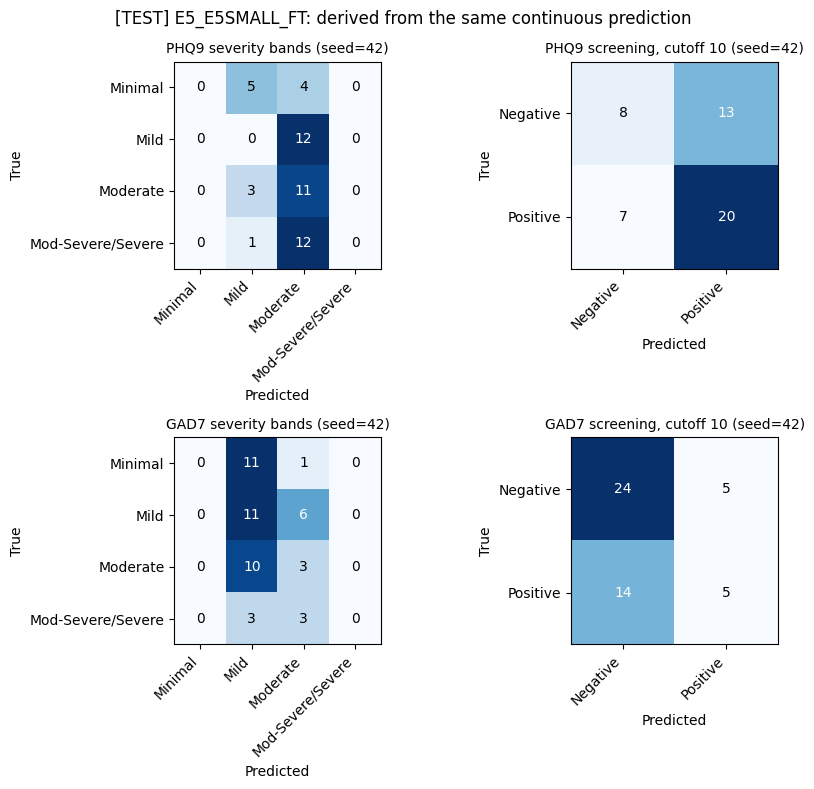

In [6]:
train_and_report("E5_E5SMALL_FT")

### e5-base, cross-validated

  E5_E5BASE_FT seed=42 target=PHQ9: 5 folds + refit
   fold 1/5  fit 298 rows / 88 people


Loading weights: 100%|██████████| 197/197 [00:00<00:00, 5113.99it/s]
[transformers] XLMRobertaForSequenceClassification LOAD REPORT from: intfloat/multilingual-e5-base
Key                        | Status     | 
---------------------------+------------+-
pooler.dense.weight        | UNEXPECTED | 
pooler.dense.bias          | UNEXPECTED | 
classifier.dense.bias      | MISSING    | 
classifier.out_proj.bias   | MISSING    | 
classifier.dense.weight    | MISSING    | 
classifier.out_proj.weight | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


    epoch  1  val_rmse(scaled) 1.0611  *
    epoch  2  val_rmse(scaled) 1.2258
    epoch  3  val_rmse(scaled) 0.9794  *
    epoch  4  val_rmse(scaled) 0.9150  *
    epoch  5  val_rmse(scaled) 1.0329
    epoch  6  val_rmse(scaled) 0.9355
    epoch  7  val_rmse(scaled) 0.9752
    epoch  8  val_rmse(scaled) 0.9703
   fold 2/5  fit 301 rows / 88 people


Loading weights: 100%|██████████| 197/197 [00:00<00:00, 12703.95it/s]
[transformers] XLMRobertaForSequenceClassification LOAD REPORT from: intfloat/multilingual-e5-base
Key                        | Status     | 
---------------------------+------------+-
pooler.dense.weight        | UNEXPECTED | 
pooler.dense.bias          | UNEXPECTED | 
classifier.dense.bias      | MISSING    | 
classifier.out_proj.bias   | MISSING    | 
classifier.dense.weight    | MISSING    | 
classifier.out_proj.weight | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


    epoch  1  val_rmse(scaled) 0.8045  *
    epoch  2  val_rmse(scaled) 0.6723  *
    epoch  3  val_rmse(scaled) 0.7554
    epoch  4  val_rmse(scaled) 0.7219
    epoch  5  val_rmse(scaled) 0.7722
    epoch  6  val_rmse(scaled) 0.7615
   fold 3/5  fit 304 rows / 89 people


...

Loading weights: 100%|██████████| 197/197 [00:00<00:00, 14586.95it/s]
[transformers] XLMRobertaForSequenceClassification LOAD REPORT from: intfloat/multilingual-e5-base
Key                        | Status     | 
---------------------------+------------+-
pooler.dense.weight        | UNEXPECTED | 
pooler.dense.bias          | UNEXPECTED | 
classifier.dense.bias      | MISSING    | 
classifier.out_proj.bias   | MISSING    | 
classifier.dense.weight    | MISSING    | 
classifier.out_proj.weight | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


    epoch  1  (refit, no early stopping)
    epoch  2  (refit, no early stopping)
    epoch  3  (refit, no early stopping)
    -> [CV] rmse 4.156   [TEST] rmse 4.318  mae 3.462  r2 0.263  (4.9 min)
E5_E5BASE_FT done in 9.3 min
[TEST] E5_E5BASE_FT: RMSE / MAE / R2 on the 48 held-out participants


rmse           mae            r2       
target   GAD7   PHQ9   GAD7   PHQ9   GAD7   PHQ9
seed                                            
42      4.318  4.533  3.462  3.777  0.263  0.319

[CROSS-VALIDATION on training data] out-of-fold RMSE, and the epoch budget each fold chose. This is not a test score.


,,cv_rmse,cv_r2,fold_epochs,refit_epochs
target,seed,,,,
PHQ9,42,4.8412,0.3389,"[4, 2, 3, 3, 2]",3
GAD7,42,4.1556,0.2951,"[8, 3, 3, 3, 2]",3


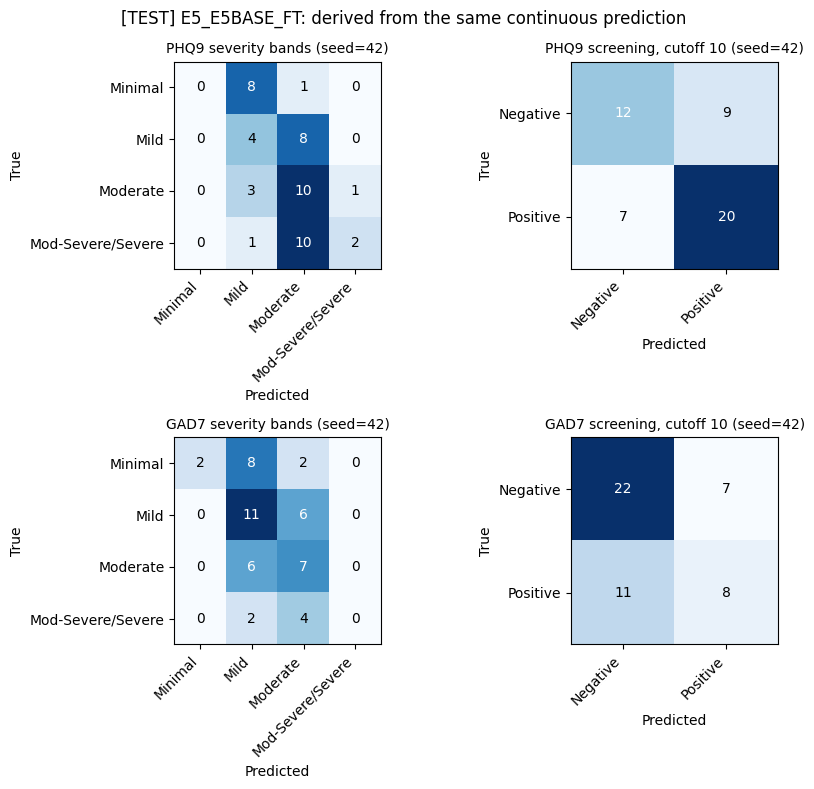

In [7]:
train_and_report("E5_E5BASE_FT")

### BETO, cross-validated

  E5_BETO_FT seed=42 target=PHQ9: 5 folds + refit
   fold 1/5  fit 298 rows / 88 people


Loading weights: 100%|██████████| 197/197 [00:00<00:00, 10938.86it/s]
[transformers] BertForSequenceClassification LOAD REPORT from: dccuchile/bert-base-spanish-wwm-cased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.decoder.bias               | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.decoder.weight             | UNEXPECTED | 
bert.pooler.dense.bias                     | MISSING    | 
classifier.weight                          | MISSING    | 
bert.pooler.dense.weight                   | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from differe

    epoch  1  val_rmse(scaled) 1.0430  *
    epoch  2  val_rmse(scaled) 1.1343
    epoch  3  val_rmse(scaled) 0.9054  *
    epoch  4  val_rmse(scaled) 0.8962  *
    epoch  5  val_rmse(scaled) 0.9617
    epoch  6  val_rmse(scaled) 0.9061
    epoch  7  val_rmse(scaled) 0.9430
    epoch  8  val_rmse(scaled) 1.1409
   fold 2/5  fit 301 rows / 88 people


Loading weights: 100%|██████████| 197/197 [00:00<00:00, 24193.42it/s]
[transformers] BertForSequenceClassification LOAD REPORT from: dccuchile/bert-base-spanish-wwm-cased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.decoder.bias               | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.decoder.weight             | UNEXPECTED | 
bert.pooler.dense.bias                     | MISSING    | 
classifier.weight                          | MISSING    | 
bert.pooler.dense.weight                   | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from differe

    epoch  1  val_rmse(scaled) 0.8432  *
    epoch  2  val_rmse(scaled) 0.7799  *
    epoch  3  val_rmse(scaled) 0.8004
    epoch  4  val_rmse(scaled) 0.7525  *
    epoch  5  val_rmse(scaled) 0.7842
    epoch  6  val_rmse(scaled) 0.8114
    epoch  7  val_rmse(scaled) 0.8384
    epoch  8  val_rmse(scaled) 0.7772
   fold 3/5  fit 304 rows / 89 people


...

Loading weights: 100%|██████████| 197/197 [00:00<00:00, 8377.81it/s]
[transformers] BertForSequenceClassification LOAD REPORT from: dccuchile/bert-base-spanish-wwm-cased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.decoder.bias               | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.decoder.weight             | UNEXPECTED | 
bert.pooler.dense.bias                     | MISSING    | 
classifier.weight                          | MISSING    | 
bert.pooler.dense.weight                   | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from differen

    epoch  1  (refit, no early stopping)
    epoch  2  (refit, no early stopping)
    epoch  3  (refit, no early stopping)
    -> [CV] rmse 4.227   [TEST] rmse 4.308  mae 3.468  r2 0.267  (3.4 min)
E5_BETO_FT done in 7.3 min
[TEST] E5_BETO_FT: RMSE / MAE / R2 on the 48 held-out participants


rmse           mae            r2       
target   GAD7   PHQ9   GAD7   PHQ9   GAD7   PHQ9
seed                                            
42      4.308  4.439  3.468  3.841  0.267  0.347

[CROSS-VALIDATION on training data] out-of-fold RMSE, and the epoch budget each fold chose. This is not a test score.


,,cv_rmse,cv_r2,fold_epochs,refit_epochs
target,seed,,,,
PHQ9,42,4.8861,0.3266,"[4, 4, 3, 9, 2]",4
GAD7,42,4.2274,0.2705,"[7, 3, 1, 5, 1]",3


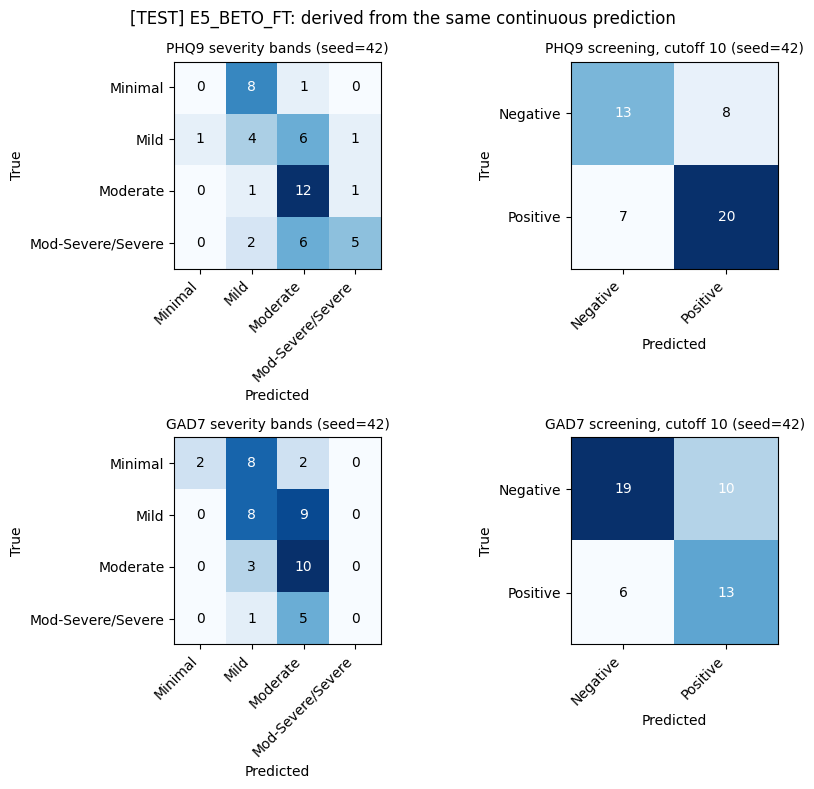

In [8]:
train_and_report("E5_BETO_FT")

### BERTIN, cross-validated

  E5_BERTIN_FT seed=42 target=PHQ9: 5 folds + refit
   fold 1/5  fit 298 rows / 88 people


Loading weights: 100%|██████████| 197/197 [00:00<00:00, 5161.08it/s]
[transformers] RobertaForSequenceClassification LOAD REPORT from: bertin-project/bertin-roberta-base-spanish
Key                        | Status     | 
---------------------------+------------+-
lm_head.bias               | UNEXPECTED | 
lm_head.dense.weight       | UNEXPECTED | 
lm_head.dense.bias         | UNEXPECTED | 
lm_head.layer_norm.weight  | UNEXPECTED | 
lm_head.layer_norm.bias    | UNEXPECTED | 
classifier.dense.bias      | MISSING    | 
classifier.out_proj.bias   | MISSING    | 
classifier.dense.weight    | MISSING    | 
classifier.out_proj.weight | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


    epoch  1  val_rmse(scaled) 1.1104  *
    epoch  2  val_rmse(scaled) 1.1272
    epoch  3  val_rmse(scaled) 1.0896  *
    epoch  4  val_rmse(scaled) 1.1244
    epoch  5  val_rmse(scaled) 1.0027  *
    epoch  6  val_rmse(scaled) 1.2230
    epoch  7  val_rmse(scaled) 1.0995
    epoch  8  val_rmse(scaled) 1.0496
    epoch  9  val_rmse(scaled) 0.9606  *
    epoch 10  val_rmse(scaled) 0.9786
    epoch 11  val_rmse(scaled) 0.9803
    epoch 12  val_rmse(scaled) 0.9729
    epoch 13  val_rmse(scaled) 1.0679
   fold 2/5  fit 301 rows / 88 people


Loading weights: 100%|██████████| 197/197 [00:00<00:00, 13731.25it/s]
[transformers] RobertaForSequenceClassification LOAD REPORT from: bertin-project/bertin-roberta-base-spanish
Key                        | Status     | 
---------------------------+------------+-
lm_head.bias               | UNEXPECTED | 
lm_head.dense.weight       | UNEXPECTED | 
lm_head.dense.bias         | UNEXPECTED | 
lm_head.layer_norm.weight  | UNEXPECTED | 
lm_head.layer_norm.bias    | UNEXPECTED | 
classifier.dense.bias      | MISSING    | 
classifier.out_proj.bias   | MISSING    | 
classifier.dense.weight    | MISSING    | 
classifier.out_proj.weight | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


    epoch  1  val_rmse(scaled) 0.8498  *
    epoch  2  val_rmse(scaled) 0.7357  *
    epoch  3  val_rmse(scaled) 0.8402
    epoch  4  val_rmse(scaled) 0.7241  *
    epoch  5  val_rmse(scaled) 0.7346
    epoch  6  val_rmse(scaled) 1.0248
    epoch  7  val_rmse(scaled) 0.7896
    epoch  8  val_rmse(scaled) 0.7381
   fold 3/5  fit 304 rows / 89 people


...

Loading weights: 100%|██████████| 197/197 [00:00<00:00, 6325.77it/s]
[transformers] RobertaForSequenceClassification LOAD REPORT from: bertin-project/bertin-roberta-base-spanish
Key                        | Status     | 
---------------------------+------------+-
lm_head.bias               | UNEXPECTED | 
lm_head.dense.weight       | UNEXPECTED | 
lm_head.dense.bias         | UNEXPECTED | 
lm_head.layer_norm.weight  | UNEXPECTED | 
lm_head.layer_norm.bias    | UNEXPECTED | 
classifier.dense.bias      | MISSING    | 
classifier.out_proj.bias   | MISSING    | 
classifier.dense.weight    | MISSING    | 
classifier.out_proj.weight | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


    epoch  1  (refit, no early stopping)
    epoch  2  (refit, no early stopping)
    epoch  3  (refit, no early stopping)
    epoch  4  (refit, no early stopping)
    epoch  5  (refit, no early stopping)
    epoch  6  (refit, no early stopping)
    epoch  7  (refit, no early stopping)
    -> [CV] rmse 4.444   [TEST] rmse 4.659  mae 3.808  r2 0.142  (4.6 min)
E5_BERTIN_FT done in 8.3 min
[TEST] E5_BERTIN_FT: RMSE / MAE / R2 on the 48 held-out participants


rmse           mae            r2       
target   GAD7   PHQ9   GAD7   PHQ9   GAD7   PHQ9
seed                                            
42      4.659  5.089  3.808  4.213  0.142  0.142

[CROSS-VALIDATION on training data] out-of-fold RMSE, and the epoch budget each fold chose. This is not a test score.


,,cv_rmse,cv_r2,fold_epochs,refit_epochs
target,seed,,,,
PHQ9,42,5.4466,0.1632,"[9, 4, 3, 4, 4]",4
GAD7,42,4.4443,0.1938,"[14, 8, 1, 7, 1]",7


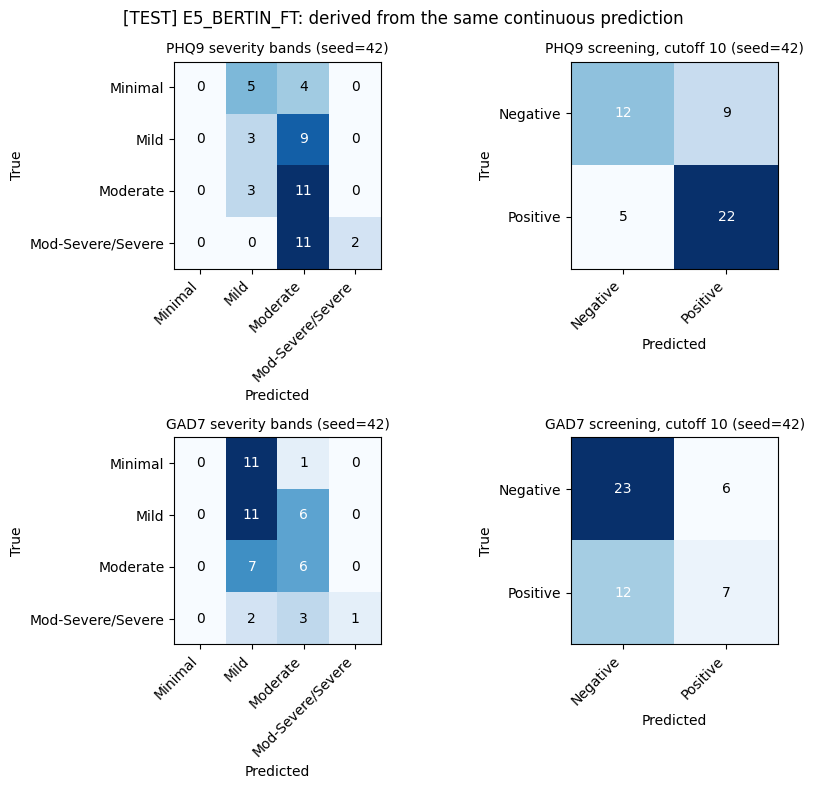

In [9]:
train_and_report("E5_BERTIN_FT")

### mDeBERTa-v3, cross-validated

  E5_MDEBERTA_FT seed=42 target=PHQ9: 5 folds + refit
   fold 1/5  fit 298 rows / 88 people


Loading weights: 100%|██████████| 198/198 [00:00<00:00, 640.08it/s]
[transformers] DebertaV2ForSequenceClassification LOAD REPORT from: microsoft/mdeberta-v3-base
Key                                        | Status     | 
-------------------------------------------+------------+-
mask_predictions.dense.bias                | UNEXPECTED | 
mask_predictions.dense.weight              | UNEXPECTED | 
lm_predictions.lm_head.bias                | UNEXPECTED | 
mask_predictions.LayerNorm.weight          | UNEXPECTED | 
lm_predictions.lm_head.LayerNorm.weight    | UNEXPECTED | 
mask_predictions.classifier.bias           | UNEXPECTED | 
mask_predictions.LayerNorm.bias            | UNEXPECTED | 
lm_predictions.lm_head.dense.bias          | UNEXPECTED | 
deberta.embeddings.word_embeddings._weight | UNEXPECTED | 
mask_predictions.classifier.weight         | UNEXPECTED | 
lm_predictions.lm_head.LayerNorm.bias      | UNEXPECTED | 
lm_predictions.lm_head.dense.weight        | UNEXPECTED | 
pooler.dens

    epoch  1  val_rmse(scaled) 1.1247  *
    epoch  2  val_rmse(scaled) 1.0943  *
    epoch  3  val_rmse(scaled) 1.0498  *
    epoch  4  val_rmse(scaled) 1.0851
    epoch  5  val_rmse(scaled) 0.8936  *
    epoch  6  val_rmse(scaled) 1.0249
    epoch  7  val_rmse(scaled) 1.0718
    epoch  8  val_rmse(scaled) 1.0780
    epoch  9  val_rmse(scaled) 1.1222
   fold 2/5  fit 301 rows / 88 people


Loading weights: 100%|██████████| 198/198 [00:00<00:00, 1285.56it/s]
[transformers] DebertaV2ForSequenceClassification LOAD REPORT from: microsoft/mdeberta-v3-base
Key                                        | Status     | 
-------------------------------------------+------------+-
mask_predictions.dense.bias                | UNEXPECTED | 
mask_predictions.dense.weight              | UNEXPECTED | 
lm_predictions.lm_head.bias                | UNEXPECTED | 
mask_predictions.LayerNorm.weight          | UNEXPECTED | 
lm_predictions.lm_head.LayerNorm.weight    | UNEXPECTED | 
mask_predictions.classifier.bias           | UNEXPECTED | 
mask_predictions.LayerNorm.bias            | UNEXPECTED | 
lm_predictions.lm_head.dense.bias          | UNEXPECTED | 
deberta.embeddings.word_embeddings._weight | UNEXPECTED | 
mask_predictions.classifier.weight         | UNEXPECTED | 
lm_predictions.lm_head.LayerNorm.bias      | UNEXPECTED | 
lm_predictions.lm_head.dense.weight        | UNEXPECTED | 
pooler.den

    epoch  1  val_rmse(scaled) 0.8274  *
    epoch  2  val_rmse(scaled) 0.8215  *
    epoch  3  val_rmse(scaled) 0.8235
    epoch  4  val_rmse(scaled) 0.7408  *
    epoch  5  val_rmse(scaled) 0.8294
    epoch  6  val_rmse(scaled) 0.8638
    epoch  7  val_rmse(scaled) 0.8795
    epoch  8  val_rmse(scaled) 0.7729
   fold 3/5  fit 304 rows / 89 people


...

Loading weights: 100%|██████████| 198/198 [00:00<00:00, 4040.87it/s]
[transformers] DebertaV2ForSequenceClassification LOAD REPORT from: microsoft/mdeberta-v3-base
Key                                        | Status     | 
-------------------------------------------+------------+-
mask_predictions.dense.bias                | UNEXPECTED | 
mask_predictions.dense.weight              | UNEXPECTED | 
lm_predictions.lm_head.bias                | UNEXPECTED | 
mask_predictions.LayerNorm.weight          | UNEXPECTED | 
lm_predictions.lm_head.LayerNorm.weight    | UNEXPECTED | 
mask_predictions.classifier.bias           | UNEXPECTED | 
mask_predictions.LayerNorm.bias            | UNEXPECTED | 
lm_predictions.lm_head.dense.bias          | UNEXPECTED | 
deberta.embeddings.word_embeddings._weight | UNEXPECTED | 
mask_predictions.classifier.weight         | UNEXPECTED | 
lm_predictions.lm_head.LayerNorm.bias      | UNEXPECTED | 
lm_predictions.lm_head.dense.weight        | UNEXPECTED | 
pooler.den

    epoch  1  (refit, no early stopping)
    epoch  2  (refit, no early stopping)
    epoch  3  (refit, no early stopping)
    epoch  4  (refit, no early stopping)
    -> [CV] rmse 4.310   [TEST] rmse 4.453  mae 3.513  r2 0.217  (24.9 min)
E5_MDEBERTA_FT done in 56.4 min
[TEST] E5_MDEBERTA_FT: RMSE / MAE / R2 on the 48 held-out participants


rmse           mae            r2       
target   GAD7   PHQ9   GAD7   PHQ9   GAD7   PHQ9
seed                                            
42      4.453  4.625  3.513  3.838  0.217  0.292

[CROSS-VALIDATION on training data] out-of-fold RMSE, and the epoch budget each fold chose. This is not a test score.


,,cv_rmse,cv_r2,fold_epochs,refit_epochs
target,seed,,,,
PHQ9,42,4.8436,0.3383,"[5, 4, 6, 6, 6]",6
GAD7,42,4.3097,0.2419,"[7, 9, 1, 4, 3]",4


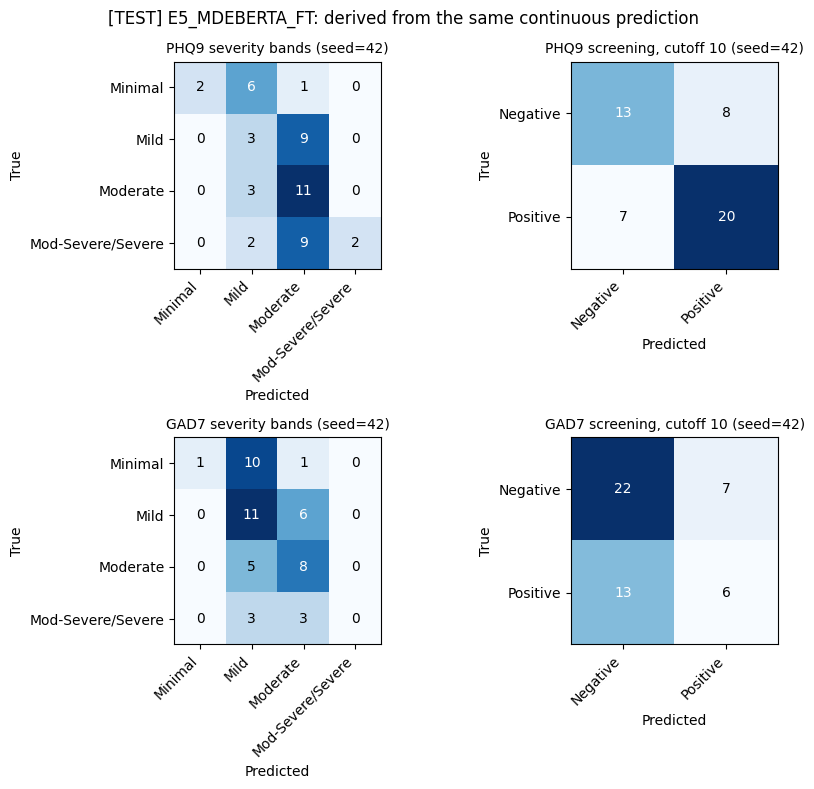

In [10]:
train_and_report("E5_MDEBERTA_FT")

### XLM-R base, cross-validated

  E5_XLMR_FT seed=42 target=PHQ9: 5 folds + refit
   fold 1/5  fit 298 rows / 88 people


Loading weights: 100%|██████████| 197/197 [00:00<00:00, 4576.14it/s]
[transformers] XLMRobertaForSequenceClassification LOAD REPORT from: xlm-roberta-base
Key                         | Status     | 
----------------------------+------------+-
lm_head.bias                | UNEXPECTED | 
roberta.pooler.dense.bias   | UNEXPECTED | 
lm_head.dense.weight        | UNEXPECTED | 
lm_head.dense.bias          | UNEXPECTED | 
lm_head.layer_norm.weight   | UNEXPECTED | 
roberta.pooler.dense.weight | UNEXPECTED | 
lm_head.layer_norm.bias     | UNEXPECTED | 
classifier.dense.bias       | MISSING    | 
classifier.out_proj.bias    | MISSING    | 
classifier.dense.weight     | MISSING    | 
classifier.out_proj.weight  | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


    epoch  1  val_rmse(scaled) 1.1180  *
    epoch  2  val_rmse(scaled) 1.1464
    epoch  3  val_rmse(scaled) 1.1297
    epoch  4  val_rmse(scaled) 1.3565
    epoch  5  val_rmse(scaled) 0.8889  *
    epoch  6  val_rmse(scaled) 0.8931
    epoch  7  val_rmse(scaled) 0.9468
    epoch  8  val_rmse(scaled) 0.9380
    epoch  9  val_rmse(scaled) 1.0996
   fold 2/5  fit 301 rows / 88 people


Loading weights: 100%|██████████| 197/197 [00:00<00:00, 16413.94it/s]
[transformers] XLMRobertaForSequenceClassification LOAD REPORT from: xlm-roberta-base
Key                         | Status     | 
----------------------------+------------+-
lm_head.bias                | UNEXPECTED | 
roberta.pooler.dense.bias   | UNEXPECTED | 
lm_head.dense.weight        | UNEXPECTED | 
lm_head.dense.bias          | UNEXPECTED | 
lm_head.layer_norm.weight   | UNEXPECTED | 
roberta.pooler.dense.weight | UNEXPECTED | 
lm_head.layer_norm.bias     | UNEXPECTED | 
classifier.dense.bias       | MISSING    | 
classifier.out_proj.bias    | MISSING    | 
classifier.dense.weight     | MISSING    | 
classifier.out_proj.weight  | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


    epoch  1  val_rmse(scaled) 0.8313  *
    epoch  2  val_rmse(scaled) 0.9209
    epoch  3  val_rmse(scaled) 0.8376
    epoch  4  val_rmse(scaled) 0.7755  *
    epoch  5  val_rmse(scaled) 0.7430  *
    epoch  6  val_rmse(scaled) 0.8994
    epoch  7  val_rmse(scaled) 0.8659
    epoch  8  val_rmse(scaled) 0.9392
    epoch  9  val_rmse(scaled) 0.8177
   fold 3/5  fit 304 rows / 89 people


...

Loading weights: 100%|██████████| 197/197 [00:00<00:00, 6057.58it/s]
[transformers] XLMRobertaForSequenceClassification LOAD REPORT from: xlm-roberta-base
Key                         | Status     | 
----------------------------+------------+-
lm_head.bias                | UNEXPECTED | 
roberta.pooler.dense.bias   | UNEXPECTED | 
lm_head.dense.weight        | UNEXPECTED | 
lm_head.dense.bias          | UNEXPECTED | 
lm_head.layer_norm.weight   | UNEXPECTED | 
roberta.pooler.dense.weight | UNEXPECTED | 
lm_head.layer_norm.bias     | UNEXPECTED | 
classifier.dense.bias       | MISSING    | 
classifier.out_proj.bias    | MISSING    | 
classifier.dense.weight     | MISSING    | 
classifier.out_proj.weight  | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


    epoch  1  (refit, no early stopping)
    epoch  2  (refit, no early stopping)
    epoch  3  (refit, no early stopping)
    epoch  4  (refit, no early stopping)
    epoch  5  (refit, no early stopping)
    -> [CV] rmse 4.139   [TEST] rmse 4.566  mae 3.523  r2 0.177  (6.2 min)
E5_XLMR_FT done in 12.9 min
[TEST] E5_XLMR_FT: RMSE / MAE / R2 on the 48 held-out participants


rmse           mae            r2      
target   GAD7   PHQ9   GAD7   PHQ9   GAD7  PHQ9
seed                                           
42      4.566  4.465  3.523  3.681  0.177  0.34

[CROSS-VALIDATION on training data] out-of-fold RMSE, and the epoch budget each fold chose. This is not a test score.


,,cv_rmse,cv_r2,fold_epochs,refit_epochs
target,seed,,,,
PHQ9,42,4.8628,0.3330,"[5, 5, 14, 7, 5]",5
GAD7,42,4.1388,0.3008,"[9, 3, 3, 9, 5]",5


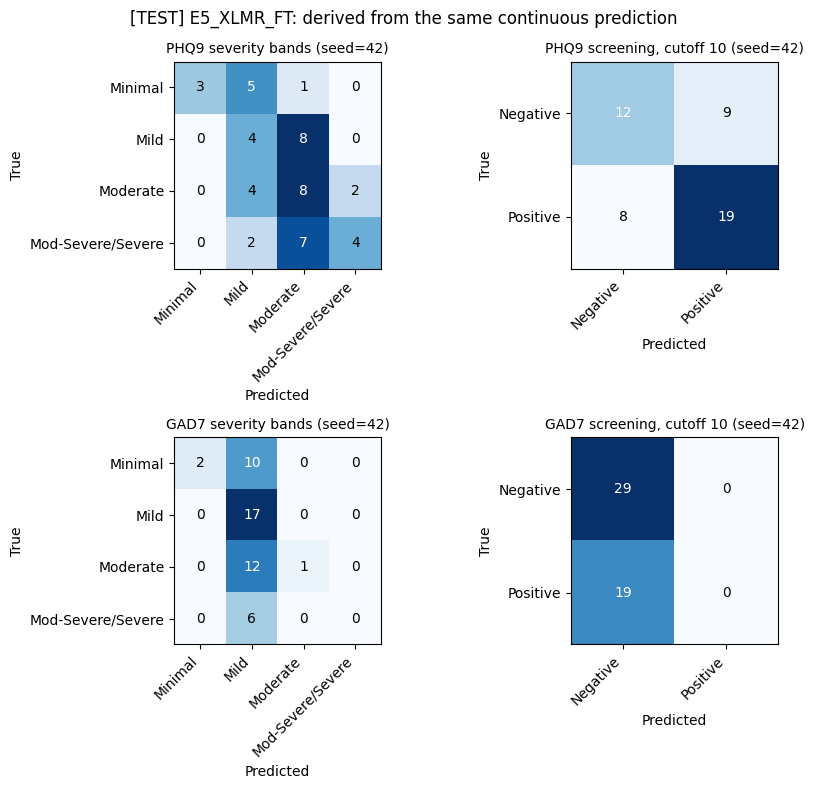

In [11]:
train_and_report("E5_XLMR_FT")

### e5-large, cross-validated

  E5_E5LARGE_FT seed=42 target=PHQ9: 5 folds + refit
   fold 1/5  fit 298 rows / 88 people


Loading weights: 100%|██████████| 389/389 [00:00<00:00, 2081.06it/s]
[transformers] XLMRobertaForSequenceClassification LOAD REPORT from: intfloat/multilingual-e5-large
Key                        | Status     | 
---------------------------+------------+-
pooler.dense.weight        | UNEXPECTED | 
pooler.dense.bias          | UNEXPECTED | 
classifier.out_proj.bias   | MISSING    | 
classifier.dense.weight    | MISSING    | 
classifier.out_proj.weight | MISSING    | 
classifier.dense.bias      | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


    epoch  1  val_rmse(scaled) 1.2578  *
    epoch  2  val_rmse(scaled) 0.9022  *
    epoch  3  val_rmse(scaled) 0.8933  *
    epoch  4  val_rmse(scaled) 0.9207
    epoch  5  val_rmse(scaled) 0.9372
    epoch  6  val_rmse(scaled) 0.9613
    epoch  7  val_rmse(scaled) 1.0057
   fold 2/5  fit 301 rows / 88 people


Loading weights: 100%|██████████| 389/389 [00:00<00:00, 5513.62it/s]
[transformers] XLMRobertaForSequenceClassification LOAD REPORT from: intfloat/multilingual-e5-large
Key                        | Status     | 
---------------------------+------------+-
pooler.dense.weight        | UNEXPECTED | 
pooler.dense.bias          | UNEXPECTED | 
classifier.out_proj.bias   | MISSING    | 
classifier.dense.weight    | MISSING    | 
classifier.out_proj.weight | MISSING    | 
classifier.dense.bias      | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


    epoch  1  val_rmse(scaled) 0.7769  *
    epoch  2  val_rmse(scaled) 0.8482
    epoch  3  val_rmse(scaled) 0.6970  *
    epoch  4  val_rmse(scaled) 0.7967
    epoch  5  val_rmse(scaled) 0.7073
    epoch  6  val_rmse(scaled) 0.7963
    epoch  7  val_rmse(scaled) 0.7774
   fold 3/5  fit 304 rows / 89 people


...

Loading weights: 100%|██████████| 389/389 [00:00<00:00, 14141.33it/s]
[transformers] XLMRobertaForSequenceClassification LOAD REPORT from: intfloat/multilingual-e5-large
Key                        | Status     | 
---------------------------+------------+-
pooler.dense.weight        | UNEXPECTED | 
pooler.dense.bias          | UNEXPECTED | 
classifier.out_proj.bias   | MISSING    | 
classifier.dense.weight    | MISSING    | 
classifier.out_proj.weight | MISSING    | 
classifier.dense.bias      | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


    epoch  1  (refit, no early stopping)
    epoch  2  (refit, no early stopping)
    epoch  3  (refit, no early stopping)
    -> [CV] rmse 4.062   [TEST] rmse 4.082  mae 2.945  r2 0.342  (19.6 min)
E5_E5LARGE_FT done in 48.2 min
[TEST] E5_E5LARGE_FT: RMSE / MAE / R2 on the 48 held-out participants


rmse           mae            r2       
target   GAD7   PHQ9   GAD7   PHQ9   GAD7   PHQ9
seed                                            
42      4.082  4.419  2.945  3.603  0.342  0.353

[CROSS-VALIDATION on training data] out-of-fold RMSE, and the epoch budget each fold chose. This is not a test score.


,,cv_rmse,cv_r2,fold_epochs,refit_epochs
target,seed,,,,
PHQ9,42,4.8399,0.3393,"[3, 3, 2, 2, 3]",3
GAD7,42,4.0623,0.3264,"[3, 3, 3, 3, 3]",3


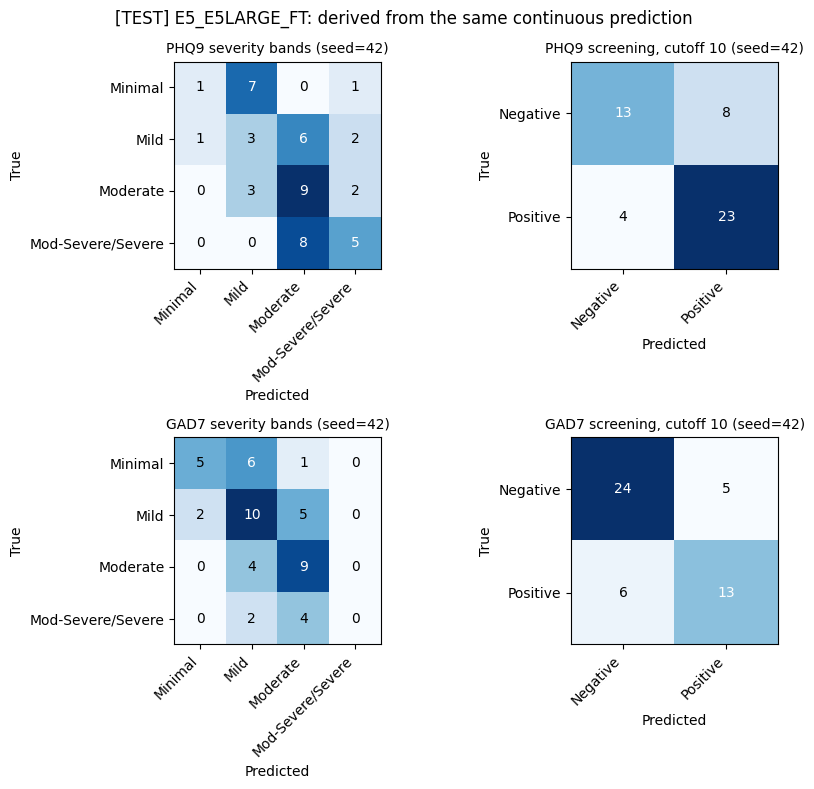

In [12]:
train_and_report("E5_E5LARGE_FT")

### XLM-R large fine-tuned

The control for e5-large. `multilingual-e5-large` is `xlm-roberta-large` with
a contrastive pretraining on top, so running the plain backbone at the same
size is what separates that pretraining from capacity.

Two things to keep in mind when reading the result. This family loads a
checkpoint through `AutoModelForSequenceClassification`, which discards the
sentence-transformer pooling and prefix that e5's extra training was built to
exploit, so the contrast is narrower than "does e5-large beat XLM-R large".
And `xlm-roberta-large` is known to be unstable to fine-tune: if this arm
scores near the mean predictor, check the per-epoch validation RMSE before
reading it as the backbone performing badly.

  E5_XLMRLARGE_FT seed=42 target=PHQ9: 5 folds + refit
   fold 1/5  fit 596 rows / 88 people


Loading weights: 100%|██████████| 389/389 [00:00<00:00, 4083.70it/s]
[transformers] XLMRobertaForSequenceClassification LOAD REPORT from: xlm-roberta-large
Key                         | Status     | 
----------------------------+------------+-
roberta.pooler.dense.bias   | UNEXPECTED | 
lm_head.bias                | UNEXPECTED | 
lm_head.dense.weight        | UNEXPECTED | 
roberta.pooler.dense.weight | UNEXPECTED | 
lm_head.dense.bias          | UNEXPECTED | 
lm_head.layer_norm.bias     | UNEXPECTED | 
lm_head.layer_norm.weight   | UNEXPECTED | 
classifier.dense.bias       | MISSING    | 
classifier.dense.weight     | MISSING    | 
classifier.out_proj.weight  | MISSING    | 
classifier.out_proj.bias    | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


    epoch  1  val_rmse(scaled) 1.1668  *
    epoch  2  val_rmse(scaled) 1.1089  *
    epoch  3  val_rmse(scaled) 0.9568  *
    epoch  4  val_rmse(scaled) 0.9503  *
    epoch  5  val_rmse(scaled) 1.0129
    epoch  6  val_rmse(scaled) 0.9925
    epoch  7  val_rmse(scaled) 0.8836  *
    epoch  8  val_rmse(scaled) 0.8960
    epoch  9  val_rmse(scaled) 0.8213  *
    epoch 10  val_rmse(scaled) 0.8721
    epoch 11  val_rmse(scaled) 0.7962  *
    epoch 12  val_rmse(scaled) 0.9553
    epoch 13  val_rmse(scaled) 0.8102
    epoch 14  val_rmse(scaled) 0.8248
    epoch 15  val_rmse(scaled) 0.8912
   fold 2/5  fit 602 rows / 88 people


Loading weights: 100%|██████████| 389/389 [00:00<00:00, 17395.96it/s]
[transformers] XLMRobertaForSequenceClassification LOAD REPORT from: xlm-roberta-large
Key                         | Status     | 
----------------------------+------------+-
roberta.pooler.dense.bias   | UNEXPECTED | 
lm_head.bias                | UNEXPECTED | 
lm_head.dense.weight        | UNEXPECTED | 
roberta.pooler.dense.weight | UNEXPECTED | 
lm_head.dense.bias          | UNEXPECTED | 
lm_head.layer_norm.bias     | UNEXPECTED | 
lm_head.layer_norm.weight   | UNEXPECTED | 
classifier.dense.bias       | MISSING    | 
classifier.dense.weight     | MISSING    | 
classifier.out_proj.weight  | MISSING    | 
classifier.out_proj.bias    | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


    epoch  1  val_rmse(scaled) 0.9676  *
    epoch  2  val_rmse(scaled) 0.9217  *
    epoch  3  val_rmse(scaled) 0.9579
    epoch  4  val_rmse(scaled) 0.9072  *
    epoch  5  val_rmse(scaled) 0.8267  *
    epoch  6  val_rmse(scaled) 0.7268  *
    epoch  7  val_rmse(scaled) 0.7203  *
    epoch  8  val_rmse(scaled) 0.8137
    epoch  9  val_rmse(scaled) 0.8644
    epoch 10  val_rmse(scaled) 0.8834
    epoch 11  val_rmse(scaled) 0.8193
   fold 3/5  fit 608 rows / 89 people


...

Loading weights: 100%|██████████| 389/389 [00:00<00:00, 6276.34it/s]
[transformers] XLMRobertaForSequenceClassification LOAD REPORT from: xlm-roberta-large
Key                         | Status     | 
----------------------------+------------+-
roberta.pooler.dense.bias   | UNEXPECTED | 
lm_head.bias                | UNEXPECTED | 
lm_head.dense.weight        | UNEXPECTED | 
roberta.pooler.dense.weight | UNEXPECTED | 
lm_head.dense.bias          | UNEXPECTED | 
lm_head.layer_norm.bias     | UNEXPECTED | 
lm_head.layer_norm.weight   | UNEXPECTED | 
classifier.dense.bias       | MISSING    | 
classifier.dense.weight     | MISSING    | 
classifier.out_proj.weight  | MISSING    | 
classifier.out_proj.bias    | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


    epoch  1  (refit, no early stopping)
    epoch  2  (refit, no early stopping)
    epoch  3  (refit, no early stopping)
    -> [CV] rmse 4.287   [TEST] rmse 4.622  mae 3.768  r2 0.156  (63.1 min)
E5_XLMRLARGE_FT done in 134.4 min
[TEST] E5_XLMRLARGE_FT: RMSE / MAE / R2 on the 48 held-out participants


rmse          mae            r2       
target   GAD7  PHQ9   GAD7   PHQ9   GAD7   PHQ9
seed                                           
42      4.622  4.42  3.768  3.583  0.156  0.353

[CROSS-VALIDATION on training data] out-of-fold RMSE, and the epoch budget each fold chose. This is not a test score.


,,cv_rmse,cv_r2,fold_epochs,refit_epochs
target,seed,,,,
PHQ9,42,4.9304,0.3143,"[11, 7, 1, 4, 3]",4
GAD7,42,4.2874,0.2497,"[6, 2, 3, 3, 2]",3


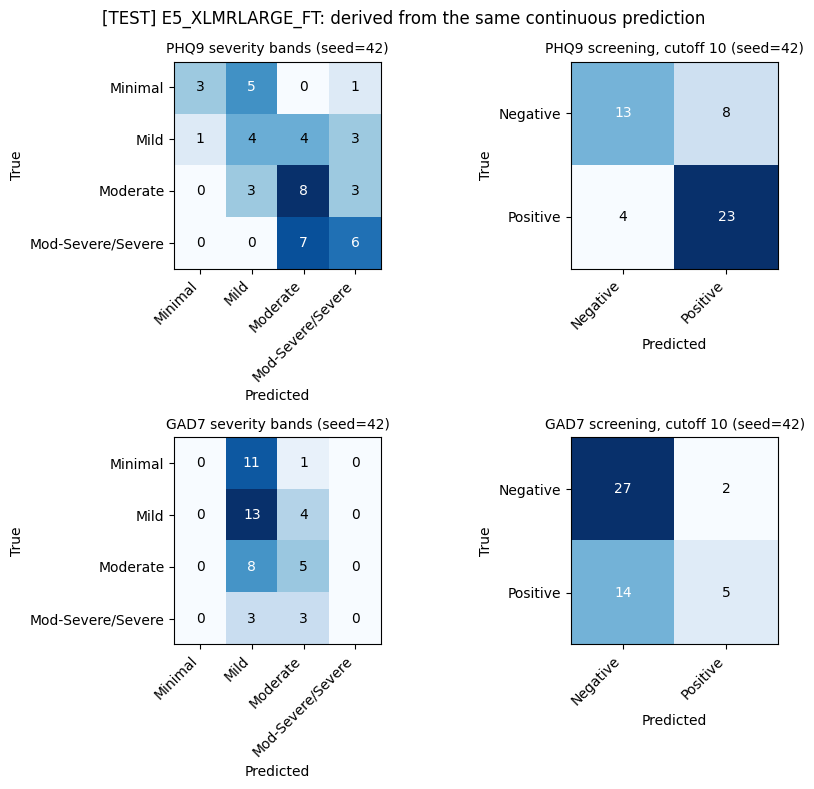

In [6]:
train_and_report("E5_XLMRLARGE_FT")

### BETO + MLM (TAPT), cross-validated

The TAPT checkpoint under the cross-validated epoch budget, paired with its
single-holdout run in notebook 04 and with `E5_BETO_FT` here. Costs k+1
trainings like every other arm in this notebook.

  E8_BETO_MLM_FT seed=42 target=PHQ9: 5 folds + refit
   fold 1/5  fit 298 rows / 88 people


Loading weights: 100%|██████████| 197/197 [00:00<00:00, 5084.29it/s]
[transformers] BertForSequenceClassification LOAD REPORT from: models/mlm_beto\ep010
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
bert.pooler.dense.bias                     | MISSING    | 
classifier.weight                          | MISSING    | 
bert.pooler.dense.weight                   | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the chec

    epoch  1  val_rmse(scaled) 0.9717  *
    epoch  2  val_rmse(scaled) 0.9968
    epoch  3  val_rmse(scaled) 0.9885
    epoch  4  val_rmse(scaled) 0.8568  *
    epoch  5  val_rmse(scaled) 0.9962
    epoch  6  val_rmse(scaled) 0.9224
    epoch  7  val_rmse(scaled) 0.8520  *
    epoch  8  val_rmse(scaled) 0.9434
    epoch  9  val_rmse(scaled) 0.8947
    epoch 10  val_rmse(scaled) 0.9434
    epoch 11  val_rmse(scaled) 0.9694
   fold 2/5  fit 301 rows / 88 people


Loading weights: 100%|██████████| 197/197 [00:00<00:00, 7842.65it/s]
[transformers] BertForSequenceClassification LOAD REPORT from: models/mlm_beto\ep010
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
bert.pooler.dense.bias                     | MISSING    | 
classifier.weight                          | MISSING    | 
bert.pooler.dense.weight                   | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the chec

    epoch  1  val_rmse(scaled) 0.8264  *
    epoch  2  val_rmse(scaled) 0.8848
    epoch  3  val_rmse(scaled) 0.7961  *
    epoch  4  val_rmse(scaled) 0.8517
    epoch  5  val_rmse(scaled) 0.8766
    epoch  6  val_rmse(scaled) 0.8269
    epoch  7  val_rmse(scaled) 0.8175
   fold 3/5  fit 304 rows / 89 people


...

Loading weights: 100%|██████████| 197/197 [00:00<00:00, 8670.01it/s]
[transformers] BertForSequenceClassification LOAD REPORT from: models/mlm_beto\ep010
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
bert.pooler.dense.bias                     | MISSING    | 
classifier.weight                          | MISSING    | 
bert.pooler.dense.weight                   | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the chec

    epoch  1  (refit, no early stopping)
    epoch  2  (refit, no early stopping)
    -> [CV] rmse 4.265   [TEST] rmse 4.442  mae 3.711  r2 0.221  (2.7 min)
E8_BETO_MLM_FT done in 6.2 min
[TEST] E8_BETO_MLM_FT: RMSE / MAE / R2 on the 48 held-out participants


rmse           mae            r2       
target   GAD7   PHQ9   GAD7   PHQ9   GAD7   PHQ9
seed                                            
42      4.442  4.654  3.711  4.037  0.221  0.283

[CROSS-VALIDATION on training data] out-of-fold RMSE, and the epoch budget each fold chose. This is not a test score.


,,cv_rmse,cv_r2,fold_epochs,refit_epochs
target,seed,,,,
PHQ9,42,4.7073,0.3750,"[7, 3, 3, 2, 5]",3
GAD7,42,4.2654,0.2574,"[5, 3, 1, 2, 1]",2


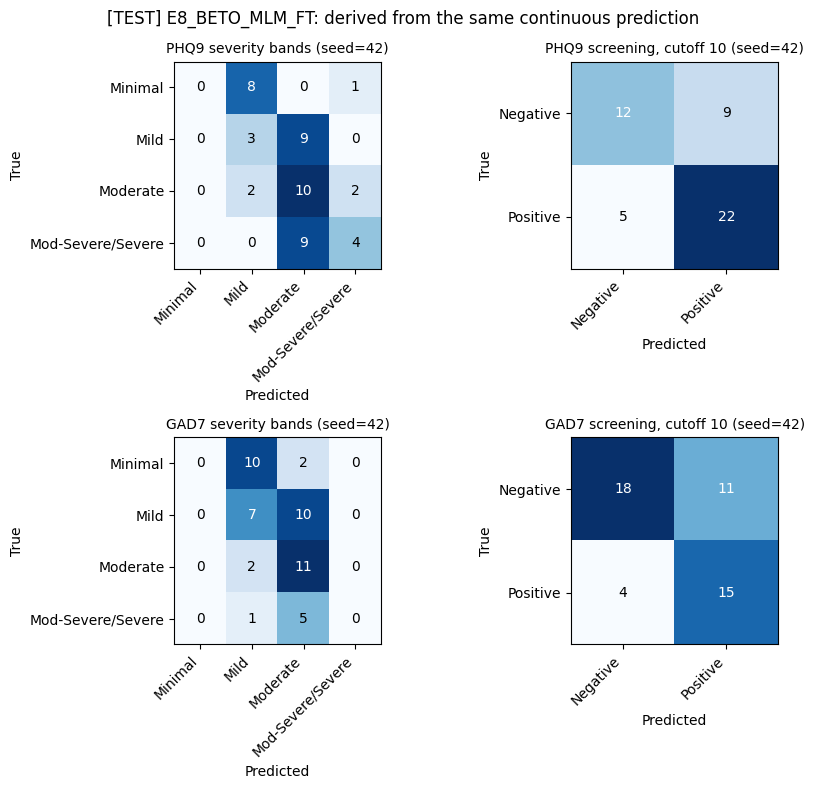

In [14]:
train_and_report("E8_BETO_MLM_FT")

### RoBERTa-es-mental, cross-validated

The externally domain-adapted Spanish model under the cross-validated epoch
budget. At 355M parameters and six trainings per target, this is the most
expensive arm here after e5-large.

  E8_ROBERTAES_MENTAL_FT seed=42 target=PHQ9: 5 folds + refit
   fold 1/5  fit 298 rows / 88 people


Loading weights: 100%|██████████| 389/389 [00:00<00:00, 4700.62it/s]
[transformers] RobertaForSequenceClassification LOAD REPORT from: ELiRF/RoBERTa-es-mental-large
Key                        | Status     | 
---------------------------+------------+-
lm_head.bias               | UNEXPECTED | 
lm_head.dense.weight       | UNEXPECTED | 
lm_head.dense.bias         | UNEXPECTED | 
lm_head.layer_norm.weight  | UNEXPECTED | 
lm_head.layer_norm.bias    | UNEXPECTED | 
classifier.out_proj.bias   | MISSING    | 
classifier.dense.weight    | MISSING    | 
classifier.out_proj.weight | MISSING    | 
classifier.dense.bias      | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


    epoch  1  val_rmse(scaled) 1.0829  *
    epoch  2  val_rmse(scaled) 0.9199  *
    epoch  3  val_rmse(scaled) 0.8942  *
    epoch  4  val_rmse(scaled) 0.8929  *
    epoch  5  val_rmse(scaled) 0.8907  *
    epoch  6  val_rmse(scaled) 0.8876  *
    epoch  7  val_rmse(scaled) 0.8964
    epoch  8  val_rmse(scaled) 0.8856  *
    epoch  9  val_rmse(scaled) 0.9336
    epoch 10  val_rmse(scaled) 0.8780  *
    epoch 11  val_rmse(scaled) 0.9147
    epoch 12  val_rmse(scaled) 0.9004
    epoch 13  val_rmse(scaled) 0.9175
    epoch 14  val_rmse(scaled) 0.8976
   fold 2/5  fit 301 rows / 88 people


Loading weights: 100%|██████████| 389/389 [00:00<00:00, 6226.14it/s]
[transformers] RobertaForSequenceClassification LOAD REPORT from: ELiRF/RoBERTa-es-mental-large
Key                        | Status     | 
---------------------------+------------+-
lm_head.bias               | UNEXPECTED | 
lm_head.dense.weight       | UNEXPECTED | 
lm_head.dense.bias         | UNEXPECTED | 
lm_head.layer_norm.weight  | UNEXPECTED | 
lm_head.layer_norm.bias    | UNEXPECTED | 
classifier.out_proj.bias   | MISSING    | 
classifier.dense.weight    | MISSING    | 
classifier.out_proj.weight | MISSING    | 
classifier.dense.bias      | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


    epoch  1  val_rmse(scaled) 0.7835  *
    epoch  2  val_rmse(scaled) 1.0482
    epoch  3  val_rmse(scaled) 0.7785  *
    epoch  4  val_rmse(scaled) 0.7323  *
    epoch  5  val_rmse(scaled) 0.8544
    epoch  6  val_rmse(scaled) 0.7870
    epoch  7  val_rmse(scaled) 0.7465
    epoch  8  val_rmse(scaled) 0.7259  *
    epoch  9  val_rmse(scaled) 0.7195  *
    epoch 10  val_rmse(scaled) 0.7534
    epoch 11  val_rmse(scaled) 0.7172  *
    epoch 12  val_rmse(scaled) 0.7583
    epoch 13  val_rmse(scaled) 0.7392
    epoch 14  val_rmse(scaled) 0.7407
    epoch 15  val_rmse(scaled) 0.7247
   fold 3/5  fit 304 rows / 89 people


...

Loading weights: 100%|██████████| 389/389 [00:00<00:00, 12437.94it/s]
[transformers] RobertaForSequenceClassification LOAD REPORT from: ELiRF/RoBERTa-es-mental-large
Key                        | Status     | 
---------------------------+------------+-
lm_head.bias               | UNEXPECTED | 
lm_head.dense.weight       | UNEXPECTED | 
lm_head.dense.bias         | UNEXPECTED | 
lm_head.layer_norm.weight  | UNEXPECTED | 
lm_head.layer_norm.bias    | UNEXPECTED | 
classifier.out_proj.bias   | MISSING    | 
classifier.dense.weight    | MISSING    | 
classifier.out_proj.weight | MISSING    | 
classifier.dense.bias      | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


    epoch  1  (refit, no early stopping)
    epoch  2  (refit, no early stopping)
    epoch  3  (refit, no early stopping)
    -> [CV] rmse 4.058   [TEST] rmse 4.230  mae 3.271  r2 0.293  (10.6 min)
E8_ROBERTAES_MENTAL_FT done in 27.4 min
[TEST] E8_ROBERTAES_MENTAL_FT: RMSE / MAE / R2 on the 48 held-out participants


rmse           mae            r2       
target  GAD7   PHQ9   GAD7   PHQ9   GAD7   PHQ9
seed                                           
42      4.23  4.433  3.271  3.684  0.293  0.349

[CROSS-VALIDATION on training data] out-of-fold RMSE, and the epoch budget each fold chose. This is not a test score.


,,cv_rmse,cv_r2,fold_epochs,refit_epochs
target,seed,,,,
PHQ9,42,4.5962,0.4041,"[10, 11, 11, 8, 3]",10
GAD7,42,4.0581,0.3278,"[6, 8, 3, 2, 3]",3


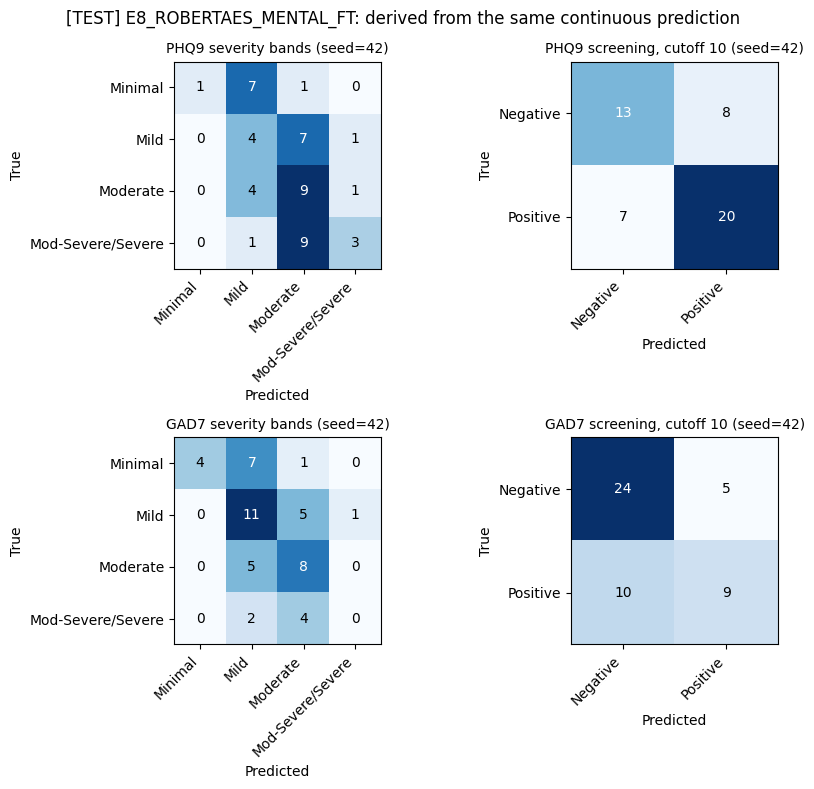

In [15]:
train_and_report("E8_ROBERTAES_MENTAL_FT")

## Cross-validated against single-holdout

The paired comparison this notebook exists for: the same checkpoint, the
same data, the same hyperparameters, differing only in how the epoch budget
was chosen and how much of the training set reached the evaluated model.

Both are read on the same 48 held-out participants, so the difference is
attributable. What it cannot tell you is whether a difference is real: each
arm is one run at seed 42, and the five-seed runs measured spreads up to
0.41 RMSE for fine-tuned arms. Treat a gap under roughly 0.4 as unresolved.

In [16]:
both = logging_utils.load_all_runs()
both = both[(both.augmentation == cfg.augmentation)
             & both.family.isin([config.FAMILY_FINETUNING, config.FAMILY_FINETUNING_CV])
             & both.encoder.isin(ARMS)]

if both.empty:
    print("Nothing logged yet for this augmentation setting.")
else:
    comparison = both.pivot_table(index=["encoder", "target"], columns="family",
                                   values="rmse").round(3)
    if set(comparison.columns) == {config.FAMILY_FINETUNING, config.FAMILY_FINETUNING_CV}:
        comparison["cv_minus_holdout"] = (comparison[config.FAMILY_FINETUNING_CV]
                                           - comparison[config.FAMILY_FINETUNING]).round(3)
    print(f"[TEST] RMSE on the {N_TEST} held-out participants. "
          f"Negative cv_minus_holdout means cross-validation won.")
    display(comparison.reindex([(a, t) for a in ARMS for t in TARGETS
                                 if (a, t) in comparison.index]))

[TEST] RMSE on the 48 held-out participants. Negative cv_minus_holdout means cross-validation won.


family                         fine-tuning  fine-tuning-cv  cv_minus_holdout
encoder                target                                               
E5_E5SMALL_FT          PHQ9          5.268           5.234            -0.034
                       GAD7          5.065           4.768            -0.297
E5_E5BASE_FT           PHQ9          4.370           4.533             0.163
                       GAD7          4.330           4.318            -0.012
E5_E5LARGE_FT          PHQ9          4.263           4.419             0.156
                       GAD7          4.860           4.082            -0.778
E5_BETO_FT             PHQ9          5.224           4.439            -0.785
                       GAD7          4.588           4.308            -0.280
E5_BERTIN_FT           PHQ9          5.325           5.089            -0.236
                       GAD7          5.064           4.659            -0.405
E5_MDEBERTA_FT         PHQ9          5.121           4.625            -0.496
                       GAD7          4.637           4.453            -0.184
E5_XLMR_FT             PHQ9          4.446           4.465             0.019
                       GAD7          4.507           4.566             0.059
E5_XLMRLARGE_FT        PHQ9            NaN           4.560               NaN
                       GAD7            NaN           4.253               NaN
E8_BETO_MLM_FT         PHQ9          4.807           4.654            -0.153
                       GAD7          5.101           4.442            -0.659
E8_ROBERTAES_MENTAL_FT PHQ9          4.537           4.433            -0.104
                       GAD7          4.245           4.230            -0.015

### Did the cross-validation estimate predict the test result?

The CV number is what you would have to rely on if there were no test set,
which is the situation any deployment is in. Plotting the two against each
other says whether it is a usable proxy at this sample size, or whether it
ranks arms differently from the held-out participants. A weak relationship
here is itself a finding, and one worth reporting: it would mean that with
48 test participants and 110 training ones, neither number pins down an
arm's quality.

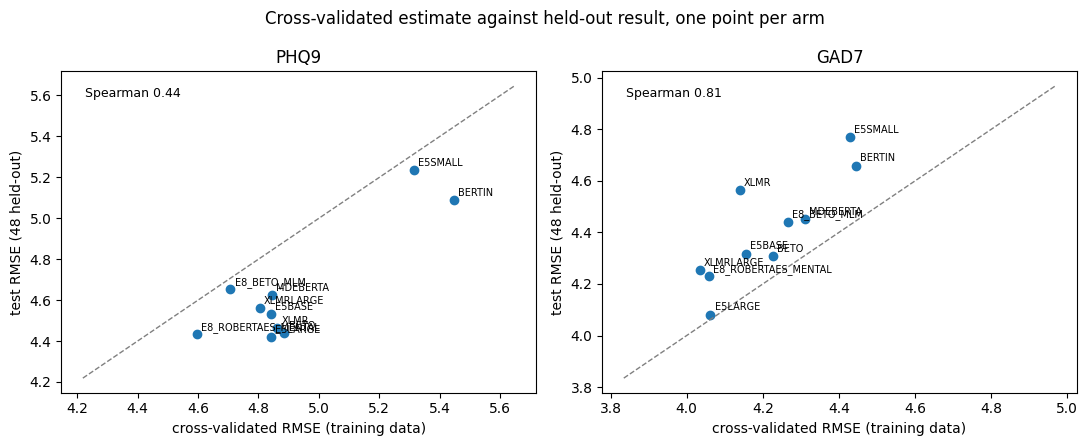

In [17]:
cv_rows = both[both.family == config.FAMILY_FINETUNING_CV].copy()
if cv_rows.empty:
    print("Run at least one arm above.")
else:
    import json
    cv_rows["cv_rmse"] = [json.loads(p)["cv_rmse"] if isinstance(p, str) else p["cv_rmse"]
                           for p in cv_rows["selected_params"]]

    fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
    for ax, target in zip(axes, TARGETS):
        subset = cv_rows[cv_rows.target == target]
        ax.scatter(subset["cv_rmse"], subset["rmse"])
        for _, row in subset.iterrows():
            ax.annotate(row["encoder"].replace("E5_", "").replace("_FT", ""),
                        (row["cv_rmse"], row["rmse"]), fontsize=7,
                        xytext=(3, 3), textcoords="offset points")
        lims = [min(subset["cv_rmse"].min(), subset["rmse"].min()) - 0.2,
                max(subset["cv_rmse"].max(), subset["rmse"].max()) + 0.2]
        ax.plot(lims, lims, linestyle="--", linewidth=1, color="grey")
        ax.set_xlabel("cross-validated RMSE (training data)")
        ax.set_ylabel("test RMSE (48 held-out)")
        ax.set_title(target)
        if len(subset) > 2:
            rho = subset[["cv_rmse", "rmse"]].corr(method="spearman").iloc[0, 1]
            ax.text(0.05, 0.92, f"Spearman {rho:.2f}", transform=ax.transAxes, fontsize=9)
    plt.suptitle("Cross-validated estimate against held-out result, one point per arm")
    plt.tight_layout()
    plt.show()